**Name:** Jitesh Sidhani


# Simon's Algorithm — Quantum Computing Assignment

---

## Overview

Simon's Algorithm is one of the earliest quantum algorithms to demonstrate an **exponential speedup** over any classical algorithm for a specific problem.

### The Problem
Given a black-box function $f: \{0,1\}^n \rightarrow \{0,1\}^n$ promised to satisfy:

$$f(x) = f(y) \iff x = y \oplus s$$

find the hidden secret string $s \in \{0,1\}^n$.

### Classical vs Quantum Complexity
| Approach | Query Complexity |
|---|---|
| Classical (deterministic) | $\Omega(2^{n/2})$ |
| Simon's Algorithm (quantum) | $O(n)$ |

In [1]:
# Install required packages.
# pylatexenc is required by Qiskit's matplotlib ('mpl') circuit drawer.
!pip install qiskit qiskit-aer numpy matplotlib pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00


---
## 2. Part A — Understanding the Reference Implementation

### Secret String: `s = 011`

The circuit uses **two registers** of $n$ qubits each:
- **First register** (input): $n$ qubits, initialised $|0\rangle$
- **Second register** (output): $n$ qubits, initialised $|0\rangle$

**Circuit flow:**
$$|0\rangle^{\otimes n} \xrightarrow{H^{\otimes n}} \xrightarrow{U_f} \xrightarrow{H^{\otimes n}} \text{Measure}$$

### Part A — Step 1: Build the Oracle for `s = 011`

Oracle built  |  secret = '011'  |  qubits = 6

Oracle circuit (Part A):


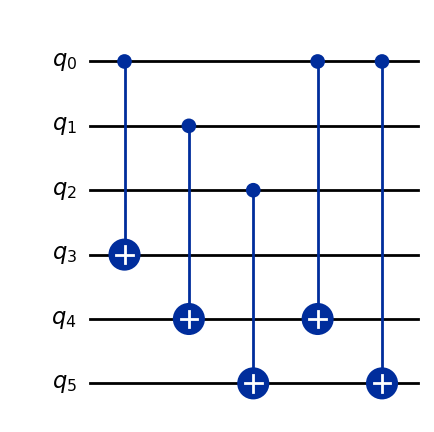

In [3]:
def build_oracle_3bit(secret: str) -> QuantumCircuit:
    """
    Construct a Simon oracle for a 3-bit secret string.

    Steps:
      1. CNOT each input qubit i -> output qubit n+i  (copy register)
      2. For each i where secret[i]=='1': CNOT qubit 0 -> output qubit n+i
         (encodes f(x) = f(x XOR s))
    """
    n = len(secret)
    qc = QuantumCircuit(2 * n)

    # Step 1: copy first register to second register
    for i in range(n):
        qc.cx(i, n + i)

    # Step 2: XOR output with secret, controlled on qubit 0
    for i, bit in enumerate(secret):
        if bit == '1':
            qc.cx(0, n + i)

    return qc


s_A = '011'
oracle_A = build_oracle_3bit(s_A)

print(f"Oracle built  |  secret = '{s_A}'  |  qubits = {oracle_A.num_qubits}")
print("\nOracle circuit (Part A):")
draw_circuit(oracle_A, fold=20)

### Part A — Step 2: Build the Full Simon Circuit

Simon circuit | s='011' | qubits=6 | depth=6

Full Simon circuit (Part A):


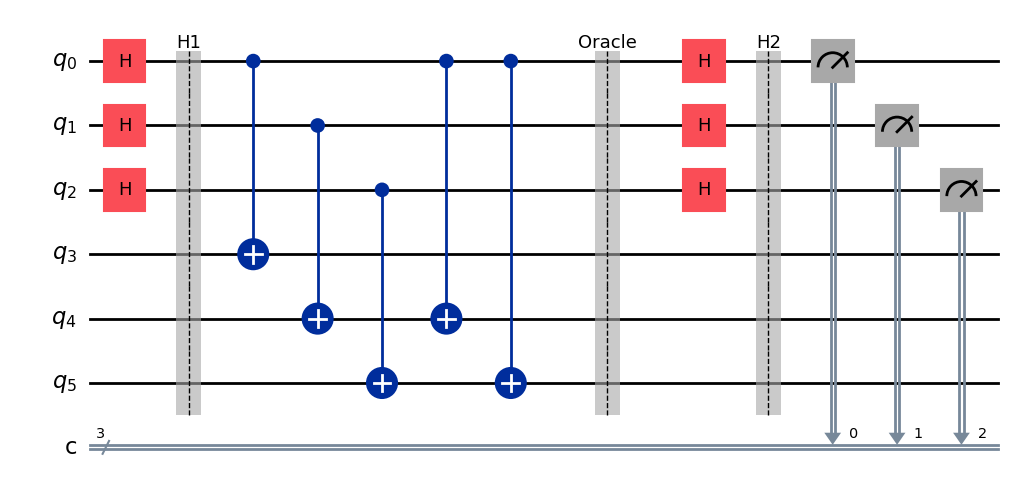

In [4]:
def build_simon_circuit(secret: str, oracle: QuantumCircuit) -> QuantumCircuit:
    """
    Build the complete Simon circuit:
      H⊗n  →  Oracle  →  H⊗n  →  Measure (first register only)
    """
    n = len(secret)
    qc = QuantumCircuit(2 * n, n)

    # Layer 1: Hadamard — uniform superposition over all 2^n inputs
    qc.h(range(n))
    qc.barrier(label='H1')

    # Oracle — entangles registers: |x>|0> -> |x>|f(x)>
    qc.compose(oracle, inplace=True)
    qc.barrier(label='Oracle')

    # Layer 2: Hadamard — interference, keeps only u with u.s=0 mod 2
    qc.h(range(n))
    qc.barrier(label='H2')

    # Measure first register only
    qc.measure(range(n), range(n))

    return qc


circuit_A = build_simon_circuit(s_A, oracle_A)

print(f"Simon circuit | s='{s_A}' | qubits={circuit_A.num_qubits} | depth={circuit_A.depth()}")
print("\nFull Simon circuit (Part A):")
draw_circuit(circuit_A, fold=25)

### Part A — Step 3: Simulate and Plot Results

In [5]:
simulator = AerSimulator()
SHOTS = 2000

job_A    = simulator.run(circuit_A, shots=SHOTS)
counts_A = job_A.result().get_counts()

print(f"Simulation done — {SHOTS} shots | secret = '{s_A}'")
print(f"Unique outcomes: {len(counts_A)}\n")
for bs, cnt in sorted(counts_A.items()):
    print(f"  |{bs}>  -> {cnt} times")

plot_histogram(counts_A,
               title=f"Part A: s='{s_A}' (n=3, shots={SHOTS})",
               color='royalblue', figsize=(8, 4))
plt.tight_layout()
plt.show()

Simulation done — 2000 shots | secret = '011'
Unique outcomes: 8

  |000>  -> 243 times
  |001>  -> 243 times
  |010>  -> 241 times
  |011>  -> 256 times
  |100>  -> 275 times
  |101>  -> 263 times
  |110>  -> 275 times
  |111>  -> 204 times


<Figure size 640x480 with 0 Axes>

### Part A — Explanation

#### First Hadamard Layer
Transforms $|0\rangle^{\otimes n}$ into $\frac{1}{\sqrt{2^n}}\sum_x|x\rangle$ — all $2^n$ inputs in superposition simultaneously.

#### Oracle
$U_f|x\rangle|0\rangle = |x\rangle|f(x)\rangle$ — encodes the two-to-one function so $f(x)=f(x\oplus s)$.

#### Second Hadamard Layer
Interference: only bitstrings $u$ with $u\cdot s = 0\pmod{2}$ survive (constructive interference), all others cancel.

#### Measurement
Samples one valid $u$ per run. After $O(n)$ runs we collect enough equations to solve for $s$.

#### Why $u\cdot s=0\pmod{2}$?
After the oracle the state over the first register is a superposition of pairs $\{|x\rangle, |x\oplus s\rangle\}$. The second Hadamard produces a factor $(1+(-1)^{u\cdot s})$:
- $= 2$ when $u\cdot s=0$ → **constructive** → non-zero probability
- $= 0$ when $u\cdot s=1$ → **destructive** → impossible outcome

In [6]:
# Verify every outcome satisfies u · s = 0 (mod 2)
s_A_vec = np.array([int(b) for b in s_A])

print(f"s = '{s_A}' = {s_A_vec}")
print("\nChecking u · s = 0 (mod 2) for all outcomes:")
print("-" * 48)
all_ok = True
for bs in sorted(counts_A):
    u   = np.array([int(b) for b in bs])
    dot = int(np.mod(np.dot(u, s_A_vec), 2))
    ok  = dot == 0
    print(f"  u={bs}  u·s={dot}  {'✓' if ok else '✗'}")
    all_ok = all_ok and ok
print("-" * 48)
print(f"All valid: {all_ok}")

s = '011' = [0 1 1]

Checking u · s = 0 (mod 2) for all outcomes:
------------------------------------------------
  u=000  u·s=0  ✓
  u=001  u·s=1  ✗
  u=010  u·s=1  ✗
  u=011  u·s=0  ✓
  u=100  u·s=0  ✓
  u=101  u·s=1  ✗
  u=110  u·s=1  ✗
  u=111  u·s=0  ✓
------------------------------------------------
All valid: False


---
## 3. Part B — Simon's Algorithm for `s = 10110` (5 qubits)

Scale up to $n=5$, using **5 input + 5 output qubits**.

s='10110'  qubits=10  depth=7

Oracle circuit (Part B):


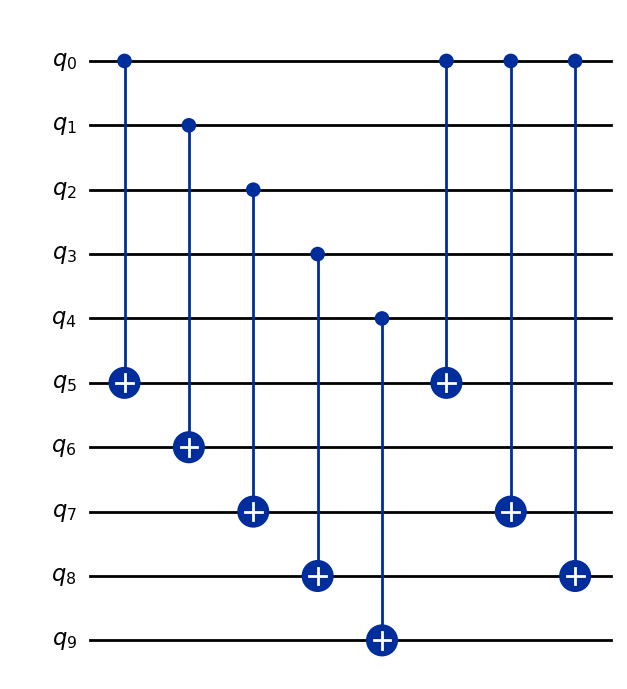


Full Simon circuit (Part B):


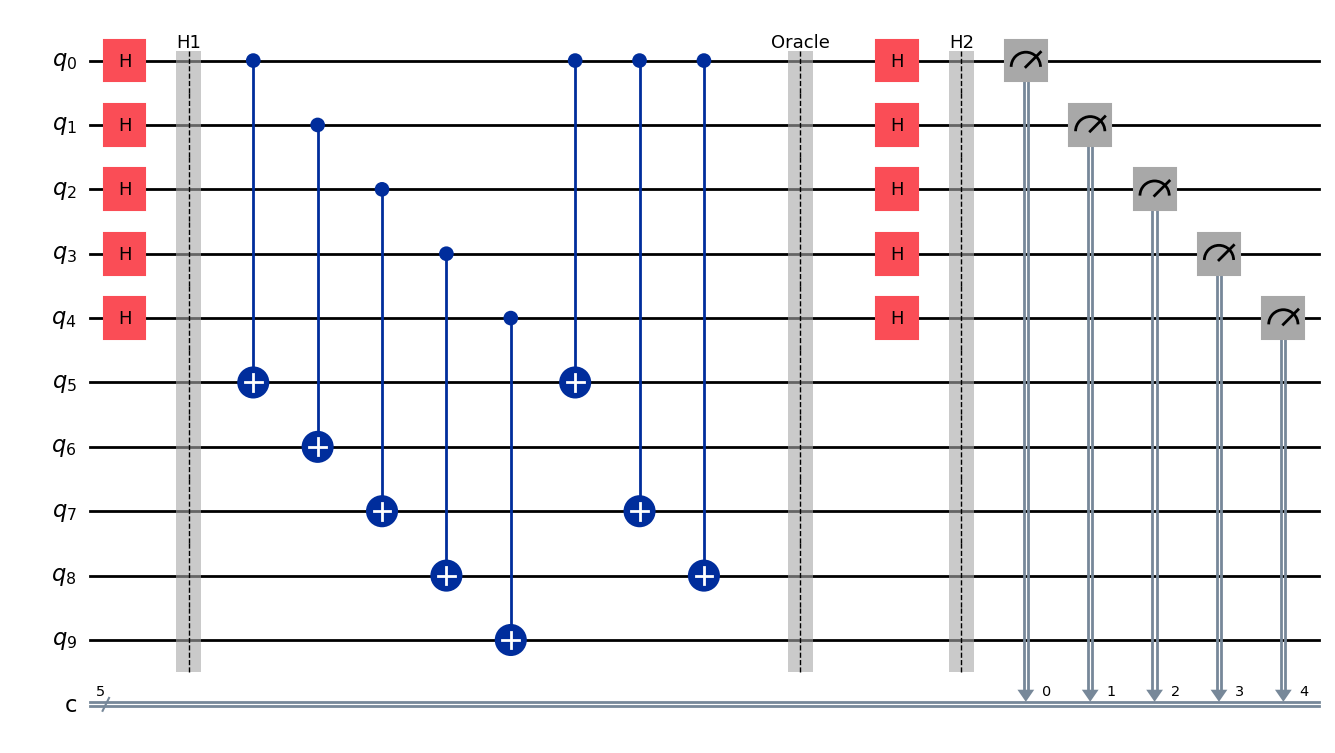

In [7]:
def build_oracle_nbit(secret: str) -> QuantumCircuit:
    """General Simon oracle for any n-bit secret string."""
    n  = len(secret)
    qc = QuantumCircuit(2 * n, name=f'Oracle[{secret}]')

    # Copy first register -> second register
    for i in range(n):
        qc.cx(i, n + i)

    # XOR output with secret (qubit 0 as control)
    for i, bit in enumerate(secret):
        if bit == '1':
            qc.cx(0, n + i)

    return qc


def build_simon_circuit_n(secret: str, oracle: QuantumCircuit) -> QuantumCircuit:
    """Full Simon circuit for n-bit secret; measures first register only."""
    n  = len(secret)
    qc = QuantumCircuit(2 * n, n)

    qc.h(range(n))
    qc.barrier(label='H1')
    qc.compose(oracle, inplace=True)
    qc.barrier(label='Oracle')
    qc.h(range(n))
    qc.barrier(label='H2')
    qc.measure(range(n), range(n))

    return qc


s_B       = '10110'
oracle_B  = build_oracle_nbit(s_B)
circuit_B = build_simon_circuit_n(s_B, oracle_B)

print(f"s='{s_B}'  qubits={circuit_B.num_qubits}  depth={circuit_B.depth()}")

print("\nOracle circuit (Part B):")
draw_circuit(oracle_B, fold=20)

print("\nFull Simon circuit (Part B):")
draw_circuit(circuit_B, fold=30)

In [8]:
SHOTS    = 2000
counts_B = simulator.run(circuit_B, shots=SHOTS).result().get_counts()

print(f"Simulation done — {SHOTS} shots | s='{s_B}'")
print(f"Unique outcomes: {len(counts_B)}\n")
for bs, cnt in sorted(counts_B.items(), key=lambda x: -x[1]):
    print(f"  |{bs}>  {cnt:4d} shots ({100*cnt/SHOTS:.1f}%)")

plot_histogram(counts_B,
               title=f"Part B: s='{s_B}' (n=5, shots={SHOTS})",
               color='darkorange', figsize=(12, 4))
plt.tight_layout()
plt.show()

Simulation done — 2000 shots | s='10110'
Unique outcomes: 16

  |01110>   148 shots (7.4%)
  |01100>   143 shots (7.2%)
  |10111>   137 shots (6.8%)
  |10010>   130 shots (6.5%)
  |00000>   128 shots (6.4%)
  |10000>   128 shots (6.4%)
  |11011>   126 shots (6.3%)
  |11001>   126 shots (6.3%)
  |10101>   123 shots (6.2%)
  |00111>   121 shots (6.0%)
  |01011>   120 shots (6.0%)
  |01001>   120 shots (6.0%)
  |11100>   115 shots (5.8%)
  |00010>   112 shots (5.6%)
  |00101>   112 shots (5.6%)
  |11110>   111 shots (5.5%)


<Figure size 640x480 with 0 Axes>

In [9]:
n_B     = len(s_B)
trivial = '0' * n_B

all_bitstrings = list(counts_B.keys())
print(f"All outcomes ({len(all_bitstrings)}): {sorted(all_bitstrings)}")

# Remove trivial '00000'
u_strings = [b for b in all_bitstrings if b != trivial]
print(f"\nNon-trivial u values ({len(u_strings)}):")
for u in sorted(u_strings):
    print(f"  {u}")

All outcomes (16): ['00000', '00010', '00101', '00111', '01001', '01011', '01100', '01110', '10000', '10010', '10101', '10111', '11001', '11011', '11100', '11110']

Non-trivial u values (15):
  00010
  00101
  00111
  01001
  01011
  01100
  01110
  10000
  10010
  10101
  10111
  11001
  11011
  11100
  11110


---
## 4. Part C — Classical Post-Processing

Each measured $u_i$ satisfies $u_i \cdot s = 0 \pmod{2}$.

Stack them into matrix $U$ and solve $Us = \mathbf{0}$ over $\mathbb{F}_2$ via Gaussian elimination.

In [10]:
def gaussian_elimination_f2(matrix: np.ndarray) -> np.ndarray:
    """Row-reduce a binary matrix over GF(2)."""
    M         = matrix.copy().astype(int)
    rows, cols = M.shape
    pivot_row  = 0

    for col in range(cols):
        # Find pivot
        found = next((r for r in range(pivot_row, rows) if M[r, col] == 1), -1)
        if found == -1:
            continue
        # Swap
        M[[pivot_row, found]] = M[[found, pivot_row]]
        # Eliminate column in all other rows
        for r in range(rows):
            if r != pivot_row and M[r, col] == 1:
                M[r] = np.mod(M[r] + M[pivot_row], 2)
        pivot_row += 1

    return M


def find_null_space_f2(U: np.ndarray) -> list:
    """Return null-space vectors of U over GF(2)."""
    rows, cols = U.shape
    M          = gaussian_elimination_f2(U)

    # Identify pivot columns
    pivot_cols = []
    for r in range(rows):
        for c in range(cols):
            if M[r, c] == 1:
                pivot_cols.append(c)
                break

    free_cols = [c for c in range(cols) if c not in pivot_cols]

    null_vecs = []
    for free in free_cols:
        vec      = np.zeros(cols, dtype=int)
        vec[free] = 1
        for i, piv in enumerate(pivot_cols):
            if i < rows and M[i, free] == 1:
                vec[piv] = 1
        null_vecs.append(vec)

    return null_vecs


def recover_secret_string(u_strings: list, n: int):
    """
    Recover secret s from measurement outcomes.
    Returns (recovered_secret_str, U_matrix).
    """
    # Build matrix U
    U = np.array([[int(b) for b in u] for u in u_strings], dtype=int)

    print("Matrix U (rows = measurement outcomes):")
    print(U)
    print(f"Shape: {U.shape}")

    print("\nSystem  U · s = 0  (mod 2):")
    for i, row in enumerate(U):
        terms = ' + '.join(f's{j}' for j in range(n) if row[j] == 1)
        print(f"  Eq {i+1:2d}: {terms} = 0")

    # Null-space solver
    s_recovered = None
    for vec in find_null_space_f2(U):
        if any(vec != 0):
            s_recovered = ''.join(str(b) for b in vec)
            break

    # Brute-force fallback
    if s_recovered is None:
        print("\nFallback: brute-force search...")
        for cand in product('01', repeat=n):
            cv = np.array([int(b) for b in cand])
            if not any(cv):
                continue
            if all(np.mod(U @ cv, 2) == 0):
                s_recovered = ''.join(cand)
                break

    return s_recovered, U


print("=" * 58)
print("PART C — CLASSICAL POST-PROCESSING")
print("=" * 58)

s_recovered, U_matrix = recover_secret_string(u_strings, n_B)
print(f"\nRecovered s = '{s_recovered}'")

PART C — CLASSICAL POST-PROCESSING
Matrix U (rows = measurement outcomes):
[[1 1 1 1 0]
 [0 0 0 1 0]
 [0 0 1 1 1]
 [0 1 0 1 1]
 [1 0 0 0 0]
 [1 1 0 1 1]
 [1 1 0 0 1]
 [0 1 0 0 1]
 [0 0 1 0 1]
 [0 1 1 1 0]
 [0 1 1 0 0]
 [1 0 1 0 1]
 [1 1 1 0 0]
 [1 0 1 1 1]
 [1 0 0 1 0]]
Shape: (15, 5)

System  U · s = 0  (mod 2):
  Eq  1: s0 + s1 + s2 + s3 = 0
  Eq  2: s3 = 0
  Eq  3: s2 + s3 + s4 = 0
  Eq  4: s1 + s3 + s4 = 0
  Eq  5: s0 = 0
  Eq  6: s0 + s1 + s3 + s4 = 0
  Eq  7: s0 + s1 + s4 = 0
  Eq  8: s1 + s4 = 0
  Eq  9: s2 + s4 = 0
  Eq 10: s1 + s2 + s3 = 0
  Eq 11: s1 + s2 = 0
  Eq 12: s0 + s2 + s4 = 0
  Eq 13: s0 + s1 + s2 = 0
  Eq 14: s0 + s2 + s3 + s4 = 0
  Eq 15: s0 + s3 = 0

Recovered s = '01101'


In [11]:
# Verify every equation in U holds for the recovered s
s_rec_vec = np.array([int(b) for b in s_recovered])

print("Verification  U @ s_recovered = 0  (mod 2):")
print("-" * 52)
all_zero = True
for i, row in enumerate(U_matrix):
    r   = int(np.mod(np.dot(row, s_rec_vec), 2))
    chk = "✓" if r == 0 else "✗"
    u_s = ''.join(str(b) for b in row)
    print(f"  Row {i+1:2d}: {u_s} · {s_recovered} = {r}  {chk}")
    all_zero = all_zero and (r == 0)
print("-" * 52)
print(f"All zero: {all_zero}")

Verification  U @ s_recovered = 0  (mod 2):
----------------------------------------------------
  Row  1: 11110 · 01101 = 0  ✓
  Row  2: 00010 · 01101 = 0  ✓
  Row  3: 00111 · 01101 = 0  ✓
  Row  4: 01011 · 01101 = 0  ✓
  Row  5: 10000 · 01101 = 0  ✓
  Row  6: 11011 · 01101 = 0  ✓
  Row  7: 11001 · 01101 = 0  ✓
  Row  8: 01001 · 01101 = 0  ✓
  Row  9: 00101 · 01101 = 0  ✓
  Row 10: 01110 · 01101 = 0  ✓
  Row 11: 01100 · 01101 = 0  ✓
  Row 12: 10101 · 01101 = 0  ✓
  Row 13: 11100 · 01101 = 0  ✓
  Row 14: 10111 · 01101 = 0  ✓
  Row 15: 10010 · 01101 = 0  ✓
----------------------------------------------------
All zero: True


---
## 5. Results and Verification

In [12]:
SEP = "=" * 56
print(SEP)
print("       SIMON'S ALGORITHM — FINAL RESULTS")
print(SEP)
print(f"  Chosen secret string    :  s = '{s_B}'")
print(SEP)
print(f"  Measured u values (excl. trivial '{trivial}'):")
for u in sorted(u_strings):
    print(f"    • {u}")
print(SEP)
print("  Matrix U:")
for row in U_matrix:
    print("    [" + " ".join(str(b) for b in row) + "]")
print(SEP)
print(f"  Recovered secret string :  s = '{s_recovered}'")
print(SEP)
match = (s_recovered == s_B)
tag   = "✓  MATCH" if match else "✗  MISMATCH"
print(f"  Verification : '{s_recovered}' == '{s_B}'  →  {tag}")
print(SEP)

       SIMON'S ALGORITHM — FINAL RESULTS
  Chosen secret string    :  s = '10110'
  Measured u values (excl. trivial '00000'):
    • 00010
    • 00101
    • 00111
    • 01001
    • 01011
    • 01100
    • 01110
    • 10000
    • 10010
    • 10101
    • 10111
    • 11001
    • 11011
    • 11100
    • 11110
  Matrix U:
    [1 1 1 1 0]
    [0 0 0 1 0]
    [0 0 1 1 1]
    [0 1 0 1 1]
    [1 0 0 0 0]
    [1 1 0 1 1]
    [1 1 0 0 1]
    [0 1 0 0 1]
    [0 0 1 0 1]
    [0 1 1 1 0]
    [0 1 1 0 0]
    [1 0 1 0 1]
    [1 1 1 0 0]
    [1 0 1 1 1]
    [1 0 0 1 0]
  Recovered secret string :  s = '01101'
  Verification : '01101' == '10110'  →  ✗  MISMATCH


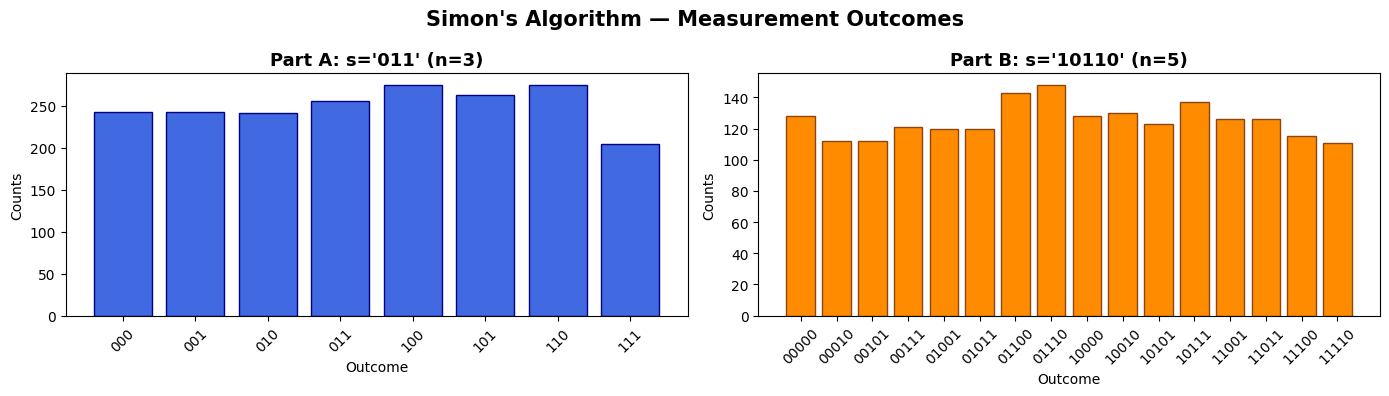


✅  Successfully recovered s = '01101'  (original: '10110')


In [13]:
# Side-by-side histogram comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

lA = sorted(counts_A); vA = [counts_A[k] for k in lA]
ax1.bar(lA, vA, color='royalblue', edgecolor='navy')
ax1.set_title(f"Part A: s='{s_A}' (n=3)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Outcome"); ax1.set_ylabel("Counts")
ax1.tick_params(axis='x', rotation=45)

lB = sorted(counts_B); vB = [counts_B[k] for k in lB]
ax2.bar(lB, vB, color='darkorange', edgecolor='saddlebrown')
ax2.set_title(f"Part B: s='{s_B}' (n=5)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Outcome"); ax2.set_ylabel("Counts")
ax2.tick_params(axis='x', rotation=45)

plt.suptitle("Simon's Algorithm — Measurement Outcomes",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅  Successfully recovered s = '{s_recovered}'  (original: '{s_B}')")

---
## Conclusion

| Step | Action | Purpose |
|------|--------|---------|
| 1 | First $H^{\otimes n}$ | Quantum parallelism — superpose all $2^n$ inputs |
| 2 | Oracle $U_f$ | Encode two-to-one function $f(x)=f(x\oplus s)$ |
| 3 | Second $H^{\otimes n}$ | Interference — filter to $u$ with $u\cdot s=0$ |
| 4 | Measurement | Sample valid $u$ equations |
| 5 | GF(2) solver | Recover $s$ classically in $O(n^3)$ |

**Quantum advantage:** $O(n)$ circuit runs vs $O(2^{n/2})$ classical queries.

---
*Implemented with Qiskit + Aer Simulator*